## Learning objectives

By the end of this case, you should be able to:

- explain how LIME constructs a local surrogate explanation
- distinguish **explanation stability** from **local fidelity**
- explain how SHAP attributes a prediction relative to a background/reference
- compare LIME and SHAP without treating their outputs as equivalent quantities
- recognize why feature attribution does not establish causality or shopper psychology

# Why Does the Model Think This Shopper Will Buy?
### Auditing Local Explanations with LIME and SHAP

**Central question:** Can we trust the explanation of an individual online-shopping prediction?

Prediction → Local explanation → Stability → Fidelity → Neighborhood plausibility → Alternative explanation → Reference sensitivity → Interpretation boundaries

**How to use this notebook:** run top-to-bottom with the repository's `.venv` kernel. We replay the approved Random Forest fit once and check it against the frozen development scores. All explanation experiments and final-test results are read from validated research artifacts; no new LIME/SHAP runs, tuning, or case selection occurs.

## 1. Real-world case

An e-commerce/product analytics team wants to understand patterns associated with whether browsing sessions end in purchase. Purchase-propensity analytics, UX investigation, personalization, customer assistance, and audits of surprising scores are possible real-world analogues.

Our data contains **completed-session aggregates**. This case supports **offline session-level prediction and explanation auditing**, not valid real-time prediction during a live visit. `Revenue` records a purchase outcome; it is not a direct measurement of shopper psychology or internal purchase intention.

A real operational system would additionally require a defined prediction moment, features known at that moment, timestamped/prospective feature construction, prospective validation, and evidence that any resulting intervention helps.

## 2. Why explainability?

| Question | What we investigate |
|---|---|
| Prediction | What score did the model assign? |
| Explanation | What features contributed to this output under a particular explanation method? |
| Explanation audit | Can we trust that representation of this individual prediction? |

**LIME:** How does the model behave in a synthetic local neighborhood around this case?

**SHAP:** How can this prediction be attributed relative to a reference/background expectation?

We will inspect what each method represents—and test its assumptions—rather than treat either as ground truth.

## 3. Dataset and prediction contract

We load the preserved UCI data and only the frozen artifacts needed for this case. The brief snapshot below establishes the target imbalance and feature groups; it is not a repeat of the full feasibility audit.

`PageValues` is excluded because its timing/provenance could not be established sufficiently for this teaching case. **This is not a finding of confirmed leakage.** The other 16 predictors remain fixed.

Data credit: Sakar & Kastro (2018), [UCI Online Shoppers Purchasing Intention Dataset, ID 468](https://doi.org/10.24432/C5F88Q), CC BY 4.0. Details: [feasibility report](../outputs/case4_online_shopping_feasibility.md), [frozen results](../outputs/case4_online_shopping_experiment_results.md), and [research implementation](../run_case4_online_shopping_experiments.py).

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Works when started from the repository root or notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'AGENTS.md').is_file() and (p / 'Data').is_dir())
ART = ROOT / 'outputs/case4_online_shopping'
RAW = ROOT / 'Data/raw/online_shoppers_intention.csv'

def read_json(name):
    return json.loads((ART / name).read_text())

def read_csv(name):
    return pd.read_csv(ART / name)

config = read_json('config.json')
preprocessing_record = read_json('preprocessing.json')
split_record = read_json('split_metadata.json')
metrics = read_json('predictive_metrics.json')

# Fail clearly if the approved inputs have changed; never regenerate them here.
for relative_path, record in read_json('artifact_manifest.json').items():
    assert hashlib.sha256((ROOT / relative_path).read_bytes()).hexdigest() == record['sha256']
assert hashlib.sha256(RAW.read_bytes()).hexdigest() == split_record['raw_sha256']
raw = pd.read_csv(RAW)
assert raw.shape == (12330, 18)
print('Preserved data and frozen research artifacts verified.')

Preserved data and frozen research artifacts verified.


In [2]:
NUMERIC = ['Administrative', 'Administrative_Duration', 'Informational',
           'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
           'BounceRates', 'ExitRates', 'SpecialDay']
CATEGORICAL = ['Month', 'OperatingSystems', 'Browser', 'Region',
               'TrafficType', 'VisitorType', 'Weekend']
FEATURES = NUMERIC + CATEGORICAL
assert FEATURES == preprocessing_record['original_features']
assert 'PageValues' not in FEATURES

snapshot = pd.DataFrame({
    'Sessions': [len(raw)], 'Purchases': [int(raw.Revenue.sum())],
    'Purchase prevalence': [raw.Revenue.mean()], 'Predictors': [len(FEATURES)]
})
display(snapshot.style.hide(axis='index').format({'Purchase prevalence': '{:.2%}'}))
display(pd.DataFrame({
    'Feature group': ['Numeric (9)', 'Categorical (7)'],
    'Variables': [', '.join(NUMERIC), ', '.join(CATEGORICAL)]
}).style.hide(axis='index'))

Sessions,Purchases,Purchase prevalence,Predictors
12330,1908,15.47%,16


Feature group,Variables
Numeric (9),"Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, SpecialDay"
Categorical (7),"Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend"


**Notice:** purchases occur in about **15.47%** of sessions. Accuracy alone would hide this imbalance.

Several signals are correlated: BounceRates/ExitRates, ProductRelated/ProductRelated_Duration, Administrative/Administrative_Duration, and Informational/Informational_Duration. We intentionally keep them because attribution among related signals is part of the question. Integer-coded browser, region, operating-system and traffic categories are nominal labels, not ordered measurements.

## 4. Train / development / test design

We **load the approved split**, not create another one. Group-aware stratification keeps identical **16-predictor vectors** in the same partition, preventing identical inputs from appearing on both sides of an evaluation. Raw rows, including duplicates, are preserved.

| Partition | Role |
|---|---|
| Train | Fit preprocessing and Random Forest. |
| Development | Select cases by frozen score rules and audit explanations. |
| Final test | Evaluate prediction after the explanation design is complete. |

The research split used outer seed 2026 and inner seed 2027. It is a fresh split relative to feasibility, but not a new independently collected dataset.

In [3]:
split = read_csv('split_assignments.csv').set_index('row_index')
assert len(split) == len(raw) and split.index.is_unique
assert split.groupby('feature_sha256').partition.nunique().max() == 1
train_ids = split.index[split.partition == 'train']
dev_ids = split.index[split.partition == 'development']

partition_table = pd.DataFrame(split_record['summary'])
display(partition_table[['partition', 'rows', 'purchases', 'prevalence']]
        .style.hide(axis='index').format({'prevalence': '{:.3%}'}))

partition,rows,purchases,prevalence
train,7398,1145,15.477%
development,2466,382,15.491%
final_test,2466,381,15.450%


## 5. Build the black box

We replay the **same approved fit** to make the predictive pipeline concrete: training-fitted one-hot encoding, numeric passthrough, and the fixed Random Forest. No settings are selected here.

The model uses encoded columns, while explanation results refer to the **original 16 conceptual features**. In the research code, categorical transport codes were decoded back to labels inside the prediction wrapper; they never became ordered model inputs. Both explainers called the complete pipeline.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

X = raw[FEATURES].copy()
X[CATEGORICAL] = X[CATEGORICAL].astype(str)  # reproduce nominal labels
preprocessing = ColumnTransformer([
    ('numeric', 'passthrough', NUMERIC),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL)
])
model_settings = dict(n_estimators=150, min_samples_leaf=3, random_state=2026, n_jobs=2)
assert model_settings == config['model']
black_box = Pipeline([('preprocessing', preprocessing),
                      ('model', RandomForestClassifier(**model_settings))])
black_box.fit(X.loc[train_ids], raw.loc[train_ids, 'Revenue'].astype(int));

In [5]:
# Verification of the approved fit, not a new evaluation or experiment.
positive_class = list(black_box.classes_).index(1)
assert positive_class == preprocessing_record['positive_class_index'] == 1
saved_dev = read_csv('development_predictions.csv').set_index('row_index')
replayed_scores = black_box.predict_proba(X.loc[saved_dev.index])[:, positive_class]
np.testing.assert_allclose(replayed_scores, saved_dev.score, atol=1e-10, rtol=0)
encoded_names = black_box.named_steps['preprocessing'].get_feature_names_out().tolist()
assert encoded_names == preprocessing_record['encoded_names']
print(f'Frozen development scores reproduced; {len(encoded_names)} encoded model columns.')

metric_labels = {'roc_auc': 'ROC-AUC', 'average_precision': 'Average Precision',
                 'brier': 'Brier', 'precision_at_0.5': 'Precision @ 0.5',
                 'recall_at_0.5': 'Recall @ 0.5'}
dev_metrics = pd.DataFrame({
    'Random Forest': {label: metrics['development'][key] for key, label in metric_labels.items()},
    'Constant training prevalence': {label: metrics['baseline_development'][key]
                                    for key, label in metric_labels.items()}
})
display(dev_metrics.style.format('{:.4f}'))

Frozen development scores reproduced; 73 encoded model columns.


,Random Forest,Constant training prevalence
ROC-AUC,0.7752,0.5000
Average Precision,0.3686,0.1549
Brier,0.1138,0.1309
Precision @ 0.5,0.5429,0.0000
Recall @ 0.5,0.0497,0.0000


**Interpret:** development Average Precision is about **0.369**, versus **0.155** for the trivial constant-score baseline: there is ranking signal worth explaining. AP summarizes the precision–recall trade-off; it is not accuracy. Brier measures squared score error, not calibration alone.

**Do not conclude:** these scores are demonstrated calibrated probabilities or this is a production-ready purchase detector. Recall at the fixed **0.5** threshold is poor. Our purpose is explanation auditing, not tuning that threshold.

## 6. Our primary shopping session

The approved primary case is **row 4002**, selected from development because its score is closest to 0.5. It is a purchase, yet the model predicts no purchase at that threshold. The case was chosen before viewing explanations, with row index breaking score ties.

We inspect a small set of raw values to connect abstract attributions to the actual session. **What made the model almost say “no purchase”?** It actually falls just below the cutoff—a difficult prediction to investigate, not evidence that borderline cases are inherently less explainable.

In [6]:
cases = read_csv('selected_cases.csv').set_index('case')
assert cases.row_index.to_dict() == {
    'near_threshold': 4002, 'high_scoring_purchaser': 8612, 'low_scoring_non_purchaser': 112
}
assert cases.row_index.map(split.partition).eq('development').all()
assert cases.feature_sha256.tolist() == cases.row_index.map(split.feature_sha256).tolist()
primary = cases.loc['near_threshold']
primary_id = int(primary.row_index)
assert primary.true_outcome == 1 and primary.predicted_class == 0 and not primary.correct
print(f'Row {primary_id}: purchase score {primary.model_score:.6f}; threshold = 0.5')
print('Observed outcome: purchase | Predicted class: no purchase | Correct: no')

important_values = ['VisitorType', 'ProductRelated', 'ProductRelated_Duration',
                    'BounceRates', 'ExitRates', 'Administrative',
                    'Administrative_Duration', 'TrafficType', 'Month']
display(raw.loc[primary_id, important_values].rename('Raw value').to_frame())

Row 4002: purchase score 0.498318; threshold = 0.5
Observed outcome: purchase | Predicted class: no purchase | Correct: no


,Raw value
VisitorType,New_Visitor
ProductRelated,13
ProductRelated_Duration,1496.833333
BounceRates,0.0
ExitRates,0.015385
Administrative,0
Administrative_Duration,0.0
TrafficType,4
Month,May


The session is labeled `New_Visitor`, includes 13 product-related pages, and has no administrative pages. Durations are shown in stored units; we do not invent a unit conversion. These observations describe the row, not the shopper's motives.

## 7. LIME: a local story

LIME approximates the black box with a simpler model near the chosen instance:

**Original session → generate perturbations → obtain black-box scores → weight nearby synthetic examples → fit a simple local surrogate → inspect its weights.**

Here, “nearby” is defined by the explainer's representation and distance—not verified similarity between real people. We load the approved **seed-0, 5,000-sample, top-5** purchase-class explanation. It used training-only quartile bins, correctly declared categories, kernel width 3.0, and a weighted linear surrogate. No perturbations are generated in this notebook.

### How was this LIME explanation created?

The research experiment used the same basic pattern below:

```python
explainer = LimeTabularExplainer(
    X_train,
    categorical_features=categorical_indices,
    categorical_names=category_names,
    random_state=0
)

explanation = explainer.explain_instance(
    shopper,
    predict_proba,
    num_features=5,
    num_samples=5000
)

In [7]:
lime_features = read_csv('lime_features.csv')
lime_runs = read_csv('lime_runs.csv')
primary_filter = (lime_features.case == 'near_threshold') & (lime_features.seed == 0) & (lime_features.samples == 5000)
lime_primary = lime_features.loc[primary_filter].sort_values('rank')
lime_diagnostics = lime_runs.loc[
    (lime_runs.case == 'near_threshold') & (lime_runs.seed == 0) & (lime_runs.samples == 5000)
].iloc[0]
assert len(lime_primary) == 5
np.testing.assert_allclose(lime_diagnostics.black_box_score, primary.model_score, atol=1e-10)
display(lime_primary[['rank', 'feature', 'predicate', 'weight', 'direction']]
        .style.hide(axis='index').format({'weight': '{:+.5f}'}))
display(pd.Series({
    'Black-box score': lime_diagnostics.black_box_score,
    'LIME surrogate prediction': lime_diagnostics.surrogate_prediction,
    'Weighted local R²': lime_diagnostics.weighted_r2,
    'Absolute error at original row': lime_diagnostics.absolute_point_error
}, name='Value').to_frame().style.format('{:.4f}'))

rank,feature,predicate,weight,direction
1,VisitorType,VisitorType=New_Visitor,+0.08135,positive
2,ProductRelated_Duration,ProductRelated_Duration > 1470.08,+0.05125,positive
3,ExitRates,0.01 < ExitRates <= 0.03,+0.02970,positive
4,BounceRates,BounceRates <= 0.00,+0.02795,positive
5,Administrative,Administrative <= 0.00,-0.02457,negative


,Value
Black-box score,0.4983
LIME surrogate prediction,0.3044
Weighted local R²,0.2645
Absolute error at original row,0.1939


**Read the weights:** `VisitorType=New_Visitor` and the displayed product-duration/rate predicates support the **local surrogate's approximation** of the purchase-class score; the Administrative predicate opposes it. Predicate labels use rounded display boundaries. These are not causal effects.

**Notice the mismatch:** the black box scores **0.4983**, but the surrogate predicts **0.3044**; weighted local R² is **0.2645**. We keep these diagnostics beside the explanation rather than hide them behind an attractive ranking.

## 8. Does LIME give the same story twice?

We inspect the **existing 20-seed experiment**. Only random seed changed: the row, model, training data, representation, bins, top-5, and 5,000-sample budget stayed fixed.

Selection frequency asks how often a feature appears. Pairwise Jaccard measures intersection/union of two top-five sets. Rank agreement uses absolute-weight rankings on their union, with omitted terms tied at rank 6. Sign consistency is conditional on selection and nonzero weight; omission is not a negative direction.

Selected in every run: ProductRelated_Duration, BounceRates, VisitorType
Mean pairwise top-5 Jaccard: 0.716
Mean union-rank Spearman: 0.755
Conditional sign consistency: 100% for every selected feature


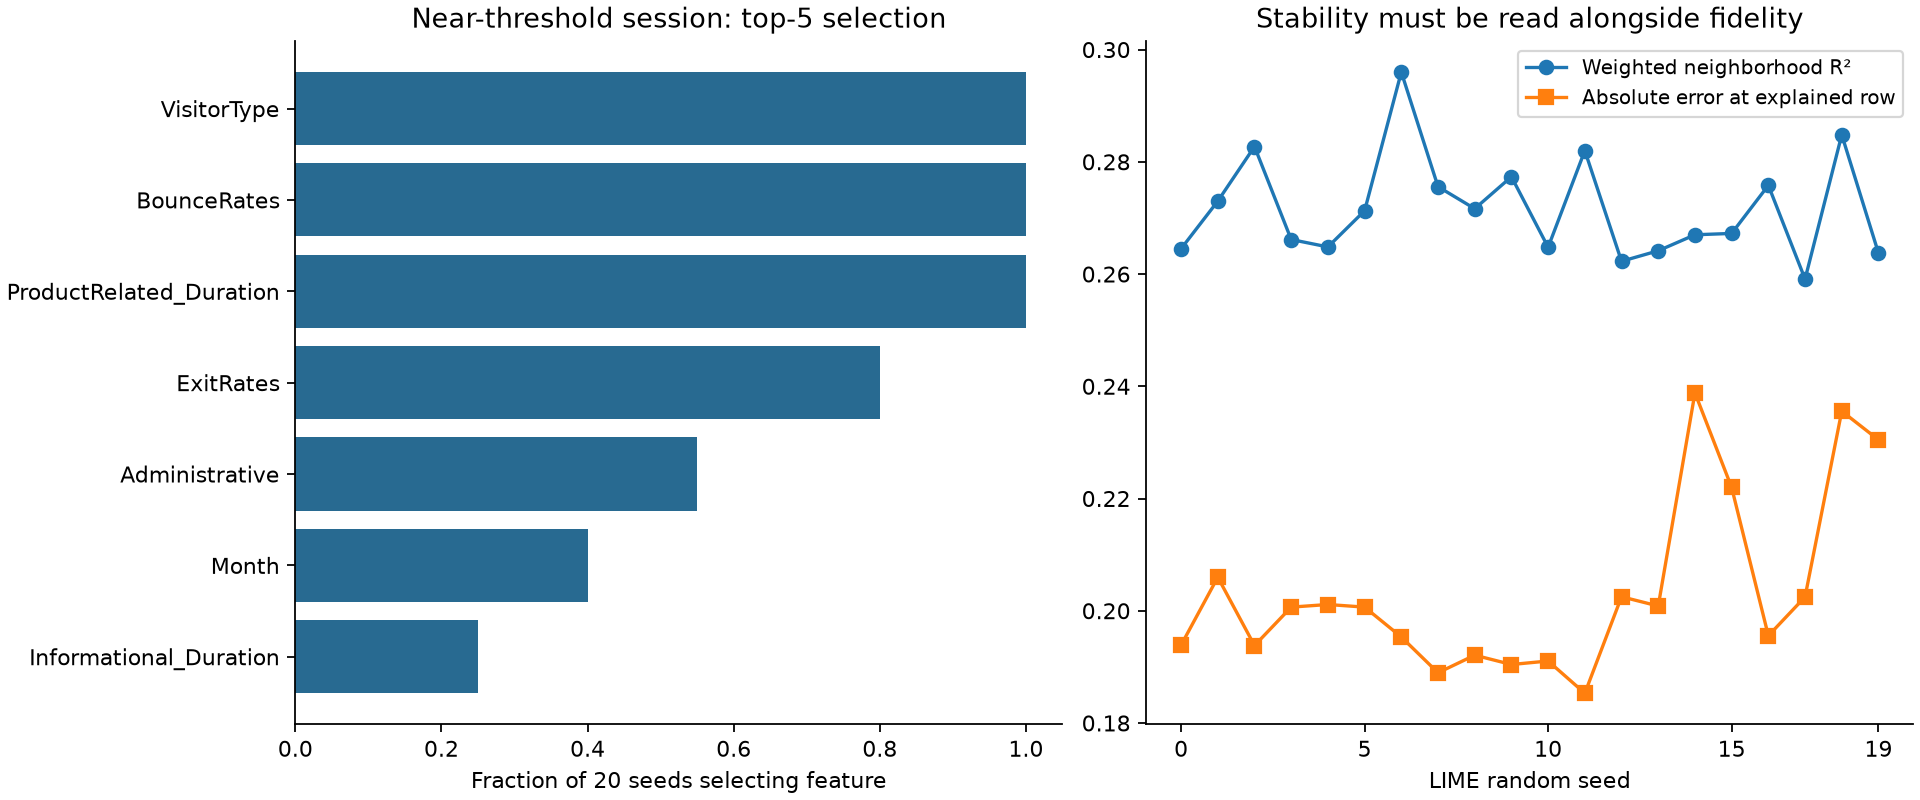

In [8]:
selection = read_csv('lime_selection_summary.csv')
stability = read_json('lime_stability_summary.json')
seed_runs = lime_runs.loc[lime_runs.experiment == 'seed_stability']
assert set(seed_runs.seed) == set(range(20)) and len(seed_runs) == 20
core = selection.loc[selection.selected_runs == 20, 'feature'].tolist()
assert set(core) == {'VisitorType', 'ProductRelated_Duration', 'BounceRates'}
print('Selected in every run:', ', '.join(core))
print(f"Mean pairwise top-5 Jaccard: {stability['pairwise_jaccard']['mean']:.3f}")
print(f"Mean union-rank Spearman: {stability['pairwise_union_rank_spearman']['mean']:.3f}")
print('Conditional sign consistency:',
      f"{selection.loc[selection.selected_runs > 0, 'sign_consistency_given_selection_nonzero'].min():.0%}",
      'for every selected feature')
display(Image(filename=str(ART / 'figures/lime_stability.png'), width=1100))

**Notice:** there is a stable core—VisitorType, ProductRelated_Duration, and BounceRates appear in all 20 runs. Other positions vary; mean Jaccard is **0.716** and mean rank agreement **0.755**.

Now separate two questions:

- **Stability:** Do repeated explanations look similar?
- **Fidelity:** How well does the surrogate approximate the black box?

The right-hand diagnostics in the figure make that second question unavoidable.

## 9. Stable does not mean faithful

We examine fidelity across those same saved runs. Weighted local R² measures fit to black-box scores in the weighted synthetic neighborhood; it is not predictive accuracy on real shoppers. Original-point error measures how far the surrogate misses the very score being explained.

In [9]:
fidelity_summary = pd.DataFrame({
    'Weighted local R²': stability['weighted_r2'],
    'Absolute original-point error': stability['absolute_point_error']
}).loc[['mean', 'min', '25%', '50%', '75%', 'max']]
np.testing.assert_allclose(seed_runs.weighted_r2.mean(), fidelity_summary.loc['mean', 'Weighted local R²'])
np.testing.assert_allclose(seed_runs.absolute_point_error.mean(),
                           fidelity_summary.loc['mean', 'Absolute original-point error'])
display(fidelity_summary.style.format('{:.4f}'))

,Weighted local R²,Absolute original-point error
mean,0.2717,0.2034
min,0.2591,0.1853
25%,0.2647,0.1934
50%,0.2693,0.2006
75%,0.2762,0.2034
max,0.2960,0.2388


**Repeatability is not enough.** Mean weighted R² is about **0.272**, and mean original-point error is about **0.203** on a 0–1 score scale. The selected features and directions are fairly repeatable, but the surrogate explains only a modest share of weighted local score variation and poorly reconstructs this prediction.

For **this instance, model, neighborhood construction, and settings**, these diagnostics do not justify treating the LIME surrogate as a faithful explanation. This is not a claim that LIME is universally unreliable. Nor would high surrogate fidelity, by itself, validate the black box.

## 10. What kind of “nearby shoppers” did LIME create?

We read the recorded support audit of the primary run's **4,999 generated rows**, excluding the original row. The research callback observed the actual samples passed to the model. No samples were silently repaired.

The four checks below connect the mathematical neighborhood to behavioral plausibility; we do not need every available diagnostic.

In [10]:
support = read_csv('perturbation_support.csv').set_index('check')
checks = ['ProductRelated: fractional count', 'Administrative: fractional count',
          'Administrative: zero count, positive duration',
          'Month/SpecialDay: pair absent from train']
display(support.loc[checks, ['flagged_n', 'generated_n', 'fraction']]
        .rename(columns={'flagged_n': 'Flagged', 'generated_n': 'Generated', 'fraction': 'Share'})
        .style.format({'Share': '{:.1%}'}))

,Flagged,Generated,Share
check,,,
ProductRelated: fractional count,4993,4999,99.9%
Administrative: fractional count,2065,4999,41.3%
"Administrative: zero count, positive duration",1230,4999,24.6%
Month/SpecialDay: pair absent from train,506,4999,10.1%


About **99.9%** of ProductRelated counts and **41.3%** of Administrative counts were fractional. About **24.6%** combined zero Administrative pages with positive Administrative duration; **10.1%** had Month/SpecialDay combinations absent from training.

LIME's synthetic sessions are mathematical samples, but they can leave realistic behavioral patterns. **If the neighborhood contains unrealistic shoppers, what exactly is the surrogate learning?**

This does not invalidate every LIME explanation. It makes the perturbation distribution part of the explanation assumptions. The Month/SpecialDay flag includes off-grid SpecialDay values—not only calendar contradictions—and these rates describe one sampled neighborhood.

## 11. Does more sampling fix the problem?

We load the approved **1,000 / 5,000 / 10,000** sample-budget comparison. Seed 0 and every other setting remain fixed; the 5,000-sample run is reused. Comparisons below use that run as the anchor. Same seed does not guarantee nested identical neighborhoods when sample count changes.

In [11]:
budget_overlap = pd.DataFrame(read_json('lime_budget_comparison.json')).set_index('samples')
budget_runs = lime_runs.loc[(lime_runs.case == 'near_threshold') & (lime_runs.seed == 0)].set_index('samples')
budget_table = budget_runs[['weighted_r2', 'absolute_point_error']].join(
    budget_overlap[['shared_n', 'jaccard']]).sort_index()
display(budget_table.rename(columns={
    'weighted_r2': 'Local R²', 'absolute_point_error': 'Point error',
    'shared_n': 'Shared top-5 with 5,000', 'jaccard': 'Jaccard with 5,000'
}).style.format(precision=4))

,Local R²,Point error,"Shared top-5 with 5,000","Jaccard with 5,000"
samples,,,,
1000,0.2916,0.1938,4,0.6667
5000,0.2645,0.1939,5,1.0000
10000,0.2714,0.2244,4,0.6667


**Notice:** both other budgets replace one top-five feature, and the point error at 10,000 samples is about **0.224**, not an improvement over **0.194** at 5,000.

More Monte Carlo samples can reduce sampling variability. They do not automatically fix an unsuitable neighborhood or an inadequate local linear surrogate. This single-seed comparison shows that more sampling did not solve the problem here; it is not a theorem about every sample size.

## 12. SHAP: another question about the same prediction

Model-agnostic **Kernel SHAP** evaluates the same black box while replacing subsets of features with values from reference rows. It allocates the difference from the reference expectation among original features:

**Prediction = background/reference expectation + feature contributions.**

We load the approved Background A result: **50 actual training sessions**, sampled with seed 2026. The method used an identity link (purchase-score units), 2,080 coalition samples, `l1_reg=0.0`, and seed 2026. This is Kernel SHAP, not TreeSHAP. Its reference-relative question differs from LIME's local-surrogate question.

In [12]:
shap_values = read_csv('shap_values.csv')
shap_runs = read_csv('shap_runs.csv')
shap_primary = shap_values.loc[
    (shap_values.case == 'near_threshold') & (shap_values.background == 'A_overall_train')
].sort_values('rank')
shap_primary_run = shap_runs.loc[
    (shap_runs.case == 'near_threshold') & (shap_runs.background == 'A_overall_train')
].iloc[0]
base = shap_primary_run.base_value
reconstructed = base + shap_primary.weight.sum()
assert abs(reconstructed - primary.model_score) < config['reconstruction_tolerance']
print(f'Base {base:.6f} + contributions {shap_primary.weight.sum():.6f}'
      f' = score {reconstructed:.6f}')
print(f'Reconstruction error from saved values: {abs(reconstructed - primary.model_score):.2e}')
display(shap_primary.head(5)[['rank', 'feature', 'weight', 'direction']]
        .style.hide(axis='index').format({'weight': '{:+.5f}'}))

Base 0.173209 + contributions 0.325109 = score 0.498318
Reconstruction error from saved values: 7.45e-13


rank,feature,weight,direction
1,VisitorType,+0.16134,positive
2,ExitRates,+0.04275,positive
3,ProductRelated_Duration,+0.03934,positive
4,TrafficType,+0.02335,positive
5,BounceRates,+0.02318,positive


**Interpret:** relative to Background A's expected score **0.1732**, the contributions sum to the session's score **0.4983**. VisitorType, ExitRates, ProductRelated_Duration, TrafficType, and BounceRates are its strongest contributions, all positive. The displayed top five are a subset; reconstruction uses **all 16** terms.

**Do not conclude:** approximately zero reconstruction error establishes causal validity, realistic feature coalitions, semantic truth, or convergence of every attribution. Numerical additivity is a property of this calculation, not an explanation-truth test.

## 13. LIME vs SHAP

Now compare the **same saved row and purchase-class output** in the original feature space. We compare membership, ranks, and signs—not raw magnitudes as though they were the same quantity.

In [13]:
method_comparisons = pd.DataFrame(read_json('lime_vs_shap.json')).set_index('case')
comparison = method_comparisons.loc['near_threshold']
print(f"Top-5 overlap: {comparison.shared_n}/5 | Jaccard: {comparison.jaccard:.3f}")
print(f"Union-rank Spearman: {comparison.union_rank_spearman:.3f}")
print(f"Direction agreement on shared nonzero terms: {comparison.sign_agreement:.0%}")
display(pd.DataFrame({
    'LIME feature': lime_primary.feature.tolist(), 'LIME direction': lime_primary.direction.tolist(),
    'SHAP feature': shap_primary.head(5).feature.tolist(), 'SHAP direction': shap_primary.head(5).direction.tolist()
}, index=pd.Index(range(1, 6), name='Rank')))

Top-5 overlap: 4/5 | Jaccard: 0.667
Union-rank Spearman: 0.771
Direction agreement on shared nonzero terms: 100%


,LIME feature,LIME direction,SHAP feature,SHAP direction
Rank,,,,
1,VisitorType,positive,VisitorType,positive
2,ProductRelated_Duration,positive,ExitRates,positive
3,ExitRates,positive,ProductRelated_Duration,positive
4,BounceRates,positive,TrafficType,positive
5,Administrative,negative,BounceRates,positive


**Notice:** overlap is **4/5**, Jaccard **0.667**, rank Spearman **0.771**, and shared direction agreement **100%**. VisitorType, ProductRelated_Duration, ExitRates, and BounceRates are shared: substantial agreement, without a winner.

LIME describes surrogate behavior in a weighted synthetic neighborhood. SHAP attributes the output relative to a background expectation. A LIME predicate coefficient is not a SHAP contribution. Agreement does not erase LIME's fidelity problem; disagreement would not automatically prove either method wrong. Rank Spearman uses the same union/omitted-rank convention as before.

## 14. Compared with whom?

We load the frozen background comparison, keeping the **model, session, score, sample size, and SHAP configuration fixed**:

- **A:** 50 sampled training sessions from the overall training population.
- **B:** 50 sampled non-purchasing training sessions, **target-informed using training labels only**.

B roughly asks: “How does this session's model prediction differ from the model's expectation over sampled non-purchasing training sessions?” It does not change the model or turn a non-purchase into an intervention.

,base_value,model_score,sum_contributions
background,,,
A_overall_train,0.1732,0.4983,0.3251
B_nonpurchase_train,0.1054,0.4983,0.3929


feature,A_value,B_value
Administrative,-0.00154,+0.00314
Month,-0.00123,+0.00573
OperatingSystems,-0.00069,+0.00439


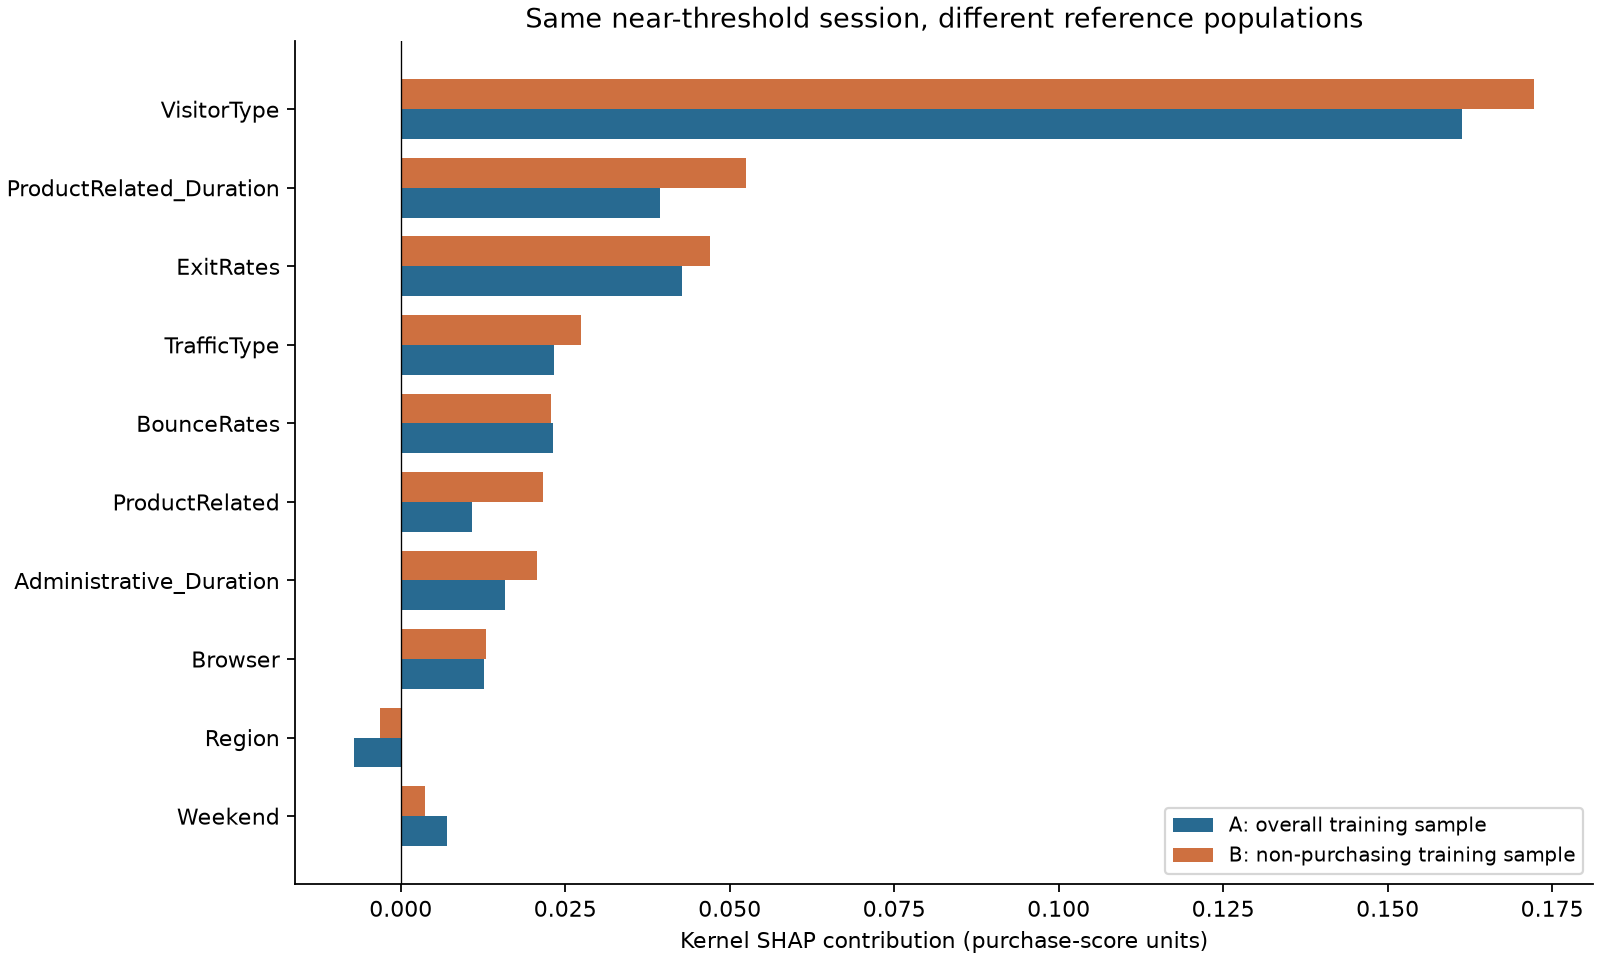

In [14]:
background_rows = read_csv('shap_background_rows.csv')
assert background_rows.row_index.map(split.partition).eq('train').all()
assert background_rows.groupby('background').size().eq(50).all()
background_runs = shap_runs.loc[shap_runs.case == 'near_threshold'].set_index('background')
for background, record in background_runs.iterrows():
    contributions = shap_values.loc[(shap_values.case == 'near_threshold') &
                                    (shap_values.background == background), 'weight'].sum()
    assert abs(record.base_value + contributions - primary.model_score) < 1e-8

display(background_runs[['base_value', 'model_score', 'sum_contributions']]
        .style.format('{:.4f}'))
background_change = read_csv('shap_background_comparison.csv')
display(background_change.loc[background_change.sign_change,
        ['feature', 'A_value', 'B_value']].style.hide(axis='index')
        .format({'A_value': '{:+.5f}', 'B_value': '{:+.5f}'}))
display(Image(filename=str(ART / 'figures/shap_background_sensitivity.png'), width=950))

The baseline changes from **0.1732 to 0.1054**, while the prediction stays **0.4983**. The top-five set remains the same; ExitRates and ProductRelated_Duration exchange ranks 2/3. Magnitudes change, and three small, lower-ranked terms change sign.

**“Why?” is often partly relative to “compared with what?”** This is a changed comparison question, not SHAP failure. These are one finite sample per population, so population differences and sampling variation are not isolated. For example, A contains 22 November sessions while B contains 8; the contrast is not a pure causal comparison of purchase status.

## 15. Correlated behavioral signals

BounceRates/ExitRates and ProductRelated/ProductRelated_Duration are strongly related in training. We inspect their saved correlations and SHAP values to see how two related predictors can both receive attribution.

In [15]:
related = read_csv('correlated_attributions.csv')
main_pairs = ['BounceRates / ExitRates', 'ProductRelated / ProductRelated_Duration']
related = related.loc[related.pair.isin(main_pairs)]
display(related[['pair', 'background', 'pearson_train', 'spearman_train',
                 'first_SHAP', 'second_SHAP', 'grouped_signed_SHAP']]
        .rename(columns={'first_SHAP': 'First feature SHAP', 'second_SHAP': 'Second feature SHAP',
                         'grouped_signed_SHAP': 'Signed sum'})
        .style.hide(axis='index').format(precision=4))

pair,background,pearson_train,spearman_train,First feature SHAP,Second feature SHAP,Signed sum
BounceRates / ExitRates,A_overall_train,0.9109,0.6002,0.0232,0.0428,0.0659
BounceRates / ExitRates,B_nonpurchase_train,0.9109,0.6002,0.0229,0.0470,0.0699
ProductRelated / ProductRelated_Duration,A_overall_train,0.8447,0.8856,0.0108,0.0393,0.0501
ProductRelated / ProductRelated_Duration,B_nonpurchase_train,0.8447,0.8856,0.0217,0.0525,0.0741


**Notice:** the rates' signed sum changes from about **+0.0659 to +0.0699**; the product count/duration sum changes from **+0.0501 to +0.0741**. Both members receive positive attribution here.

Attribution among dependent features is assumption-sensitive: references and masking can change how contributions are allocated. We have **not isolated correlation as the cause** of these differences. Grouped signed sums are descriptive totals, not causal credit or uniquely correct group-player SHAP values. No variables were removed and no new model was fitted for this comparison.

## 16. Three different shoppers

We compare only the three approved development sessions: highest-scoring purchaser, lowest-scoring non-purchaser, and nearest-to-0.5 session. The scores—not attractive explanations—determined their selection. “High-scoring” does not mean “90% confident,” and a zero score does not establish certainty.

The saved summaries use LIME seed 0 / 5,000 samples and SHAP Background A for all three.

,row_index,true_outcome,model_score,correct,LIME point error,Shared top-5,Rank agreement
case,,,,,,,
high_scoring_purchaser,8612,1,0.6054,True,0.3036,4,-0.029
low_scoring_non_purchaser,112,0,0.0000,True,0.0274,4,-0.314
near_threshold,4002,1,0.4983,False,0.1939,4,0.771


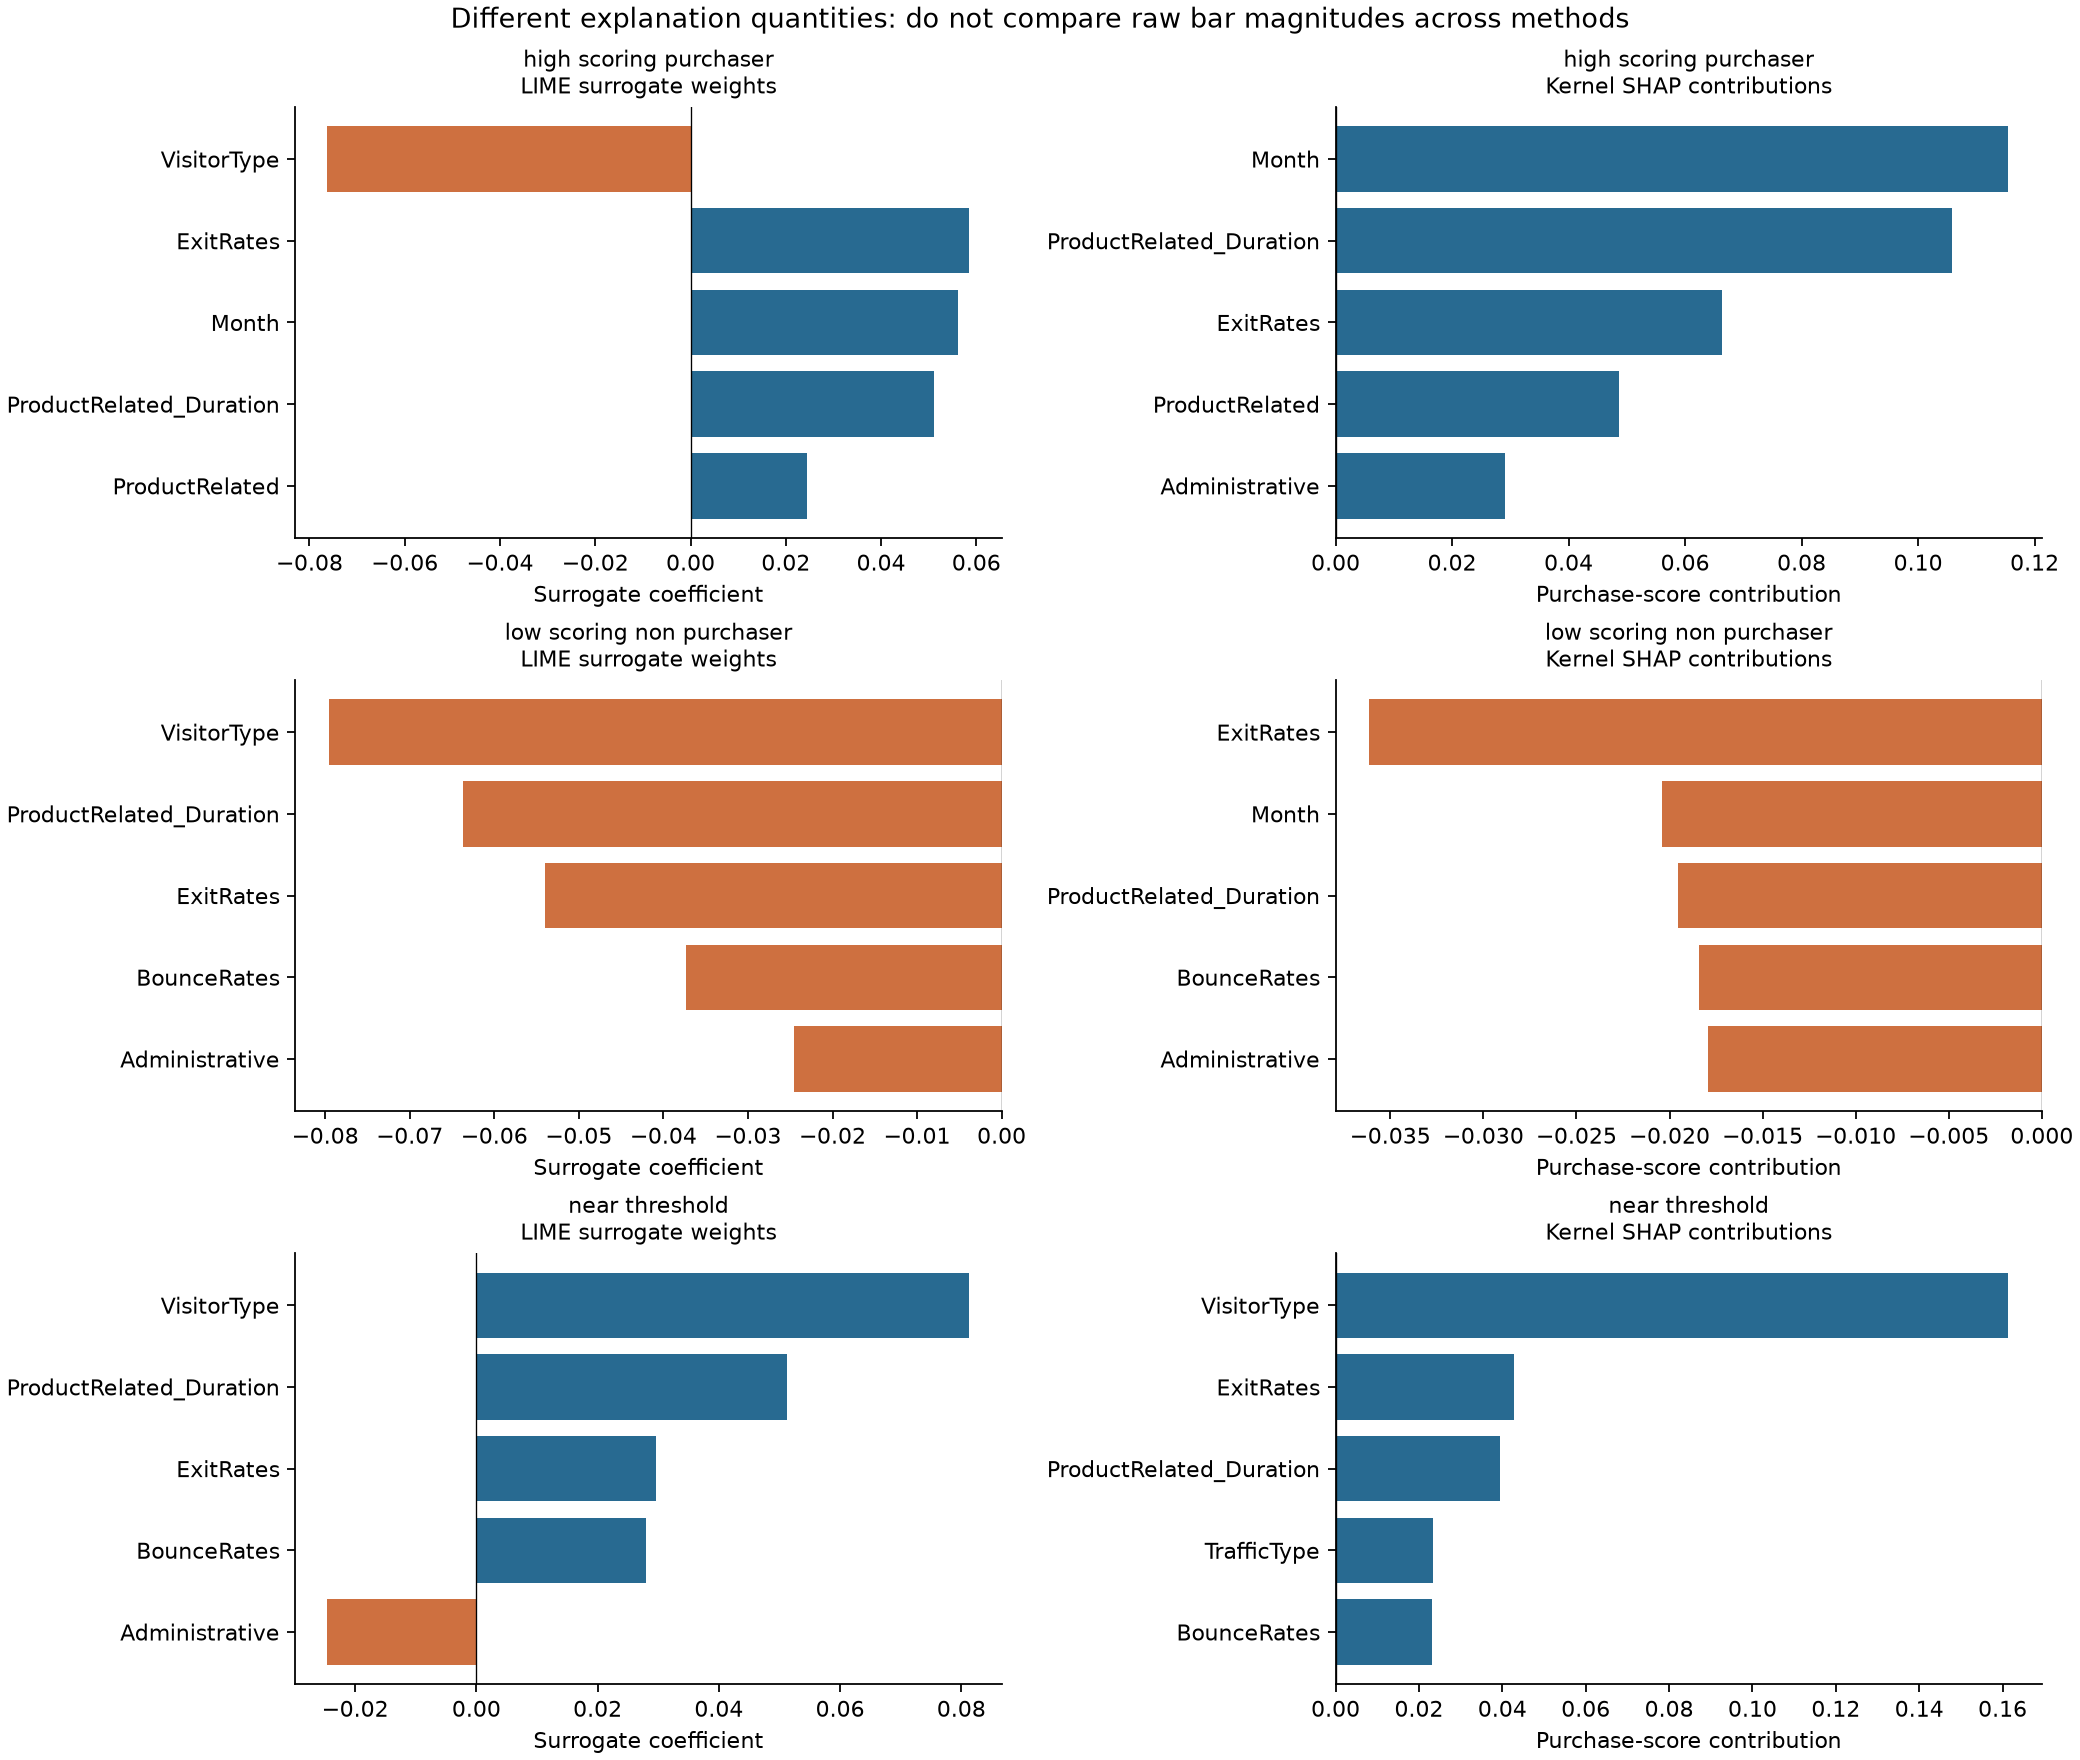

In [16]:
case_order = ['high_scoring_purchaser', 'low_scoring_non_purchaser', 'near_threshold']
compact_lime = lime_runs.loc[(lime_runs.seed == 0) & (lime_runs.samples == 5000)].set_index('case')
three_sessions = cases[['row_index', 'true_outcome', 'model_score', 'correct']].join(
    compact_lime[['absolute_point_error']]).join(
    method_comparisons[['shared_n', 'union_rank_spearman']]).loc[case_order]
display(three_sessions.rename(columns={'absolute_point_error': 'LIME point error',
                                      'shared_n': 'Shared top-5', 'union_rank_spearman': 'Rank agreement'})
        .style.format({'model_score': '{:.4f}', 'LIME point error': '{:.4f}',
                       'Rank agreement': '{:.3f}'}))
display(Image(filename=str(ART / 'figures/three_session_explanations.png'), width=1100))

All three have **4/5 top-feature overlap**, yet rank agreement varies greatly. LIME point error is about **0.304** for the high-scoring purchaser, **0.027** for the low-scoring non-purchaser, and **0.194** for the near-threshold case.

Keep four properties separate:

| Property | Question |
|---|---|
| Prediction correctness | Does the thresholded prediction match the recorded outcome? |
| Explanation stability | Does the explanation repeat under the tested changes? |
| Local surrogate fidelity | Does LIME approximate the black box well? |
| Between-method agreement | Do LIME and SHAP highlight similar features? |

**Only the near-threshold session has the 20-seed study.** We cannot infer that borderline explanations are less stable, or compare stability across these session types, from the one-run high/low summaries. Bar magnitudes also have different meanings across methods.

## 17. Final test

We now reveal the **already-frozen final-test results**. In the research workflow, final evaluation followed the completed explanation design. This notebook loads those metrics; it does not use test rows to choose cases, change settings, tune thresholds, or recalibrate.

In [17]:
final_table = pd.DataFrame({
    'Random Forest': {label: metrics['final_test'][key] for key, label in metric_labels.items()},
    'Constant training prevalence': {label: metrics['baseline_final_test'][key]
                                    for key, label in metric_labels.items()}
})
display(final_table.style.format('{:.4f}'))
display(pd.DataFrame(metrics['final_test']['confusion_matrix'],
                     index=['Actual no purchase', 'Actual purchase'],
                     columns=['Predicted no purchase', 'Predicted purchase']))

,Random Forest,Constant training prevalence
ROC-AUC,0.7535,0.5000
Average Precision,0.3314,0.1545
Brier,0.1167,0.1306
Precision @ 0.5,0.4412,0.0000
Recall @ 0.5,0.0394,0.0000


,Predicted no purchase,Predicted purchase
Actual no purchase,2066,19
Actual purchase,366,15


**Interpret:** ROC-AUC is **0.7535** and AP **0.3314**, versus test prevalence **0.1545**: the model has ranking signal beyond the trivial baseline. Brier is **0.1167**; precision at 0.5 is **0.4412**, but recall is only **0.0394**. It detects **15 of 381** purchases and misses **366**.

This demonstrates an explanation audit, not a production-ready real-time purchase intervention system. The threshold remains fixed; these results do not establish calibrated probabilities, effective interventions, or prospective validity.

## 18. What did we actually learn?

**We observed**

- Some LIME features were highly repeatable across seeds; that did not imply strong local fidelity.
- LIME's neighborhood contained behaviorally questionable combinations.
- LIME and SHAP nevertheless agreed on several dominant features.
- Changing SHAP's reference changed the baseline and some attributions.
- Correlated behavioral signals complicated attribution interpretation.

**We can say** how this trained model behaved for selected sessions, how LIME and SHAP represented those predictions under the tested assumptions, whether explanations were stable under specific tests, and where the methods agreed or disagreed.

**We cannot say** why a shopper psychologically decided to buy, that a highlighted feature caused a purchase, or that changing it will produce a purchase. Stability is not automatically fidelity; SHAP additivity is not explanation truth; this offline model is not demonstrated deployment-ready.

## 19. Real-world application

For the product analytics team, local explanations can help audit surprising predictions, inspect individual cases, detect questionable model reliance, debug model behavior, communicate departures from an expected reference, and generate hypotheses for UX/business research.

Those roles do not automatically justify interventions. **“ProductRelated_Duration contributed positively” does not establish “making the shopper spend longer on product pages will cause them to buy.”** An actionable intervention requires additional causal or experimental evidence.

A useful stakeholder report therefore includes the score, the explanation's comparison question, and its diagnostic limitations—not just a feature ranking.

## 20. Student reflection

1. LIME repeatedly selected several features. Why was that not enough to call the explanation trustworthy?
2. What is the difference between explanation stability and local fidelity?
3. What concerns do the synthetic LIME sessions raise?
4. Why can LIME and SHAP agree on important features while answering different questions?
5. Why did changing SHAP's reference population change the explanation but leave the prediction unchanged?
6. How might correlated behavioral variables complicate feature attribution?
7. What additional evidence would be required before using these explanations to design an intervention?